# RQ4, Part 2: Real Exploratory Data Analysis

Real EDA: remediation status, weakness category breakdown, remediation time distribution, disclosures by year.

**Requires `rq4_real_sec_edgar_dataset_FINAL.csv`.**

In [3]:
!pip install -q pandas matplotlib || pip install -q pandas matplotlib --break-system-packages

Real N = 113
Real remediation status: 61 remediated, 52 still open (censored)

REAL SUMMARY STATISTICS: remediation_days (remediated cases only)
count      61.0
mean      332.4
std       459.1
min         0.0
25%        92.0
50%       364.0
75%       365.0
max      2680.0
Name: remediation_days, dtype: float64

REAL FULL WEAKNESS CATEGORY COUNTS
weakness_category
Other                                       18
Unspecified                                 10
Revenue Recognition                         10
Control Environment/Staffing                10
ITGC                                         6
Control Environment                          4
Complex Transactions                         4
Income Tax                                   3
Risk Assessment                              2
Goodwill/Impairment                          2
Complex Financial Instruments (Warrants)     2
ITGC/Multiple                                1
Complex Financial Instruments                1
Account Reconciliation 

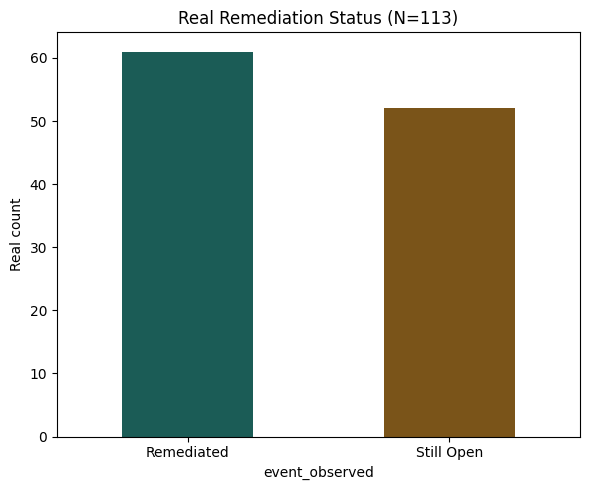

Saved rq4_eda_remediation_status.png


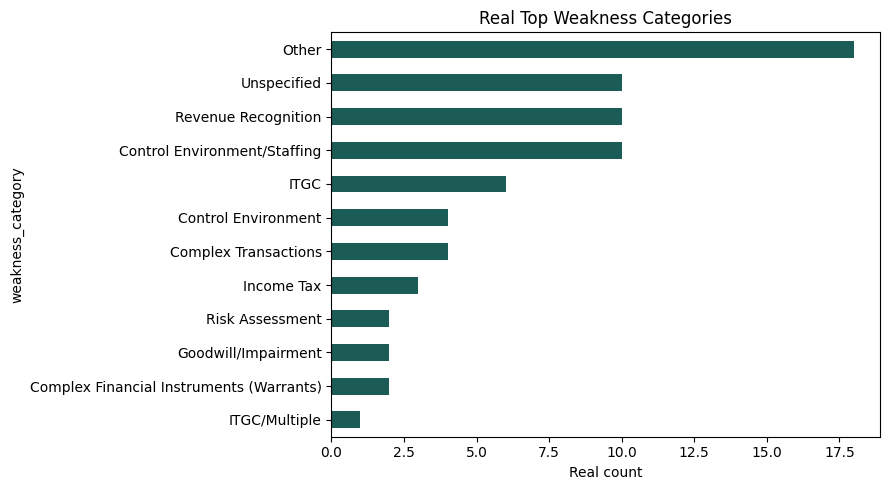

Saved rq4_eda_weakness_categories.png


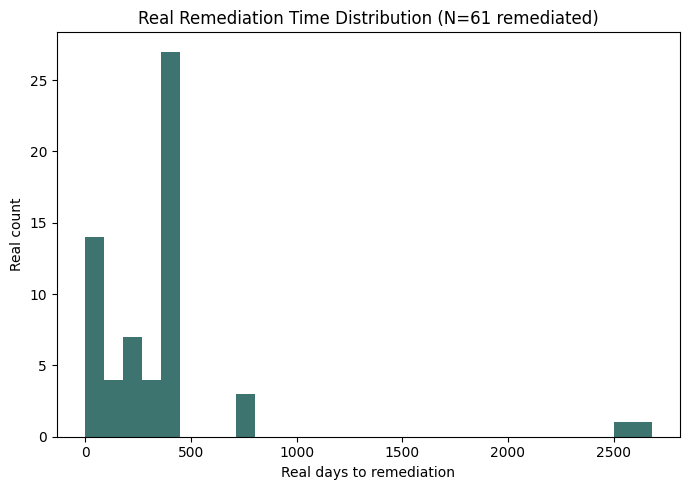

Saved rq4_eda_remediation_time.png
Real median: 364 days, real mean: 332 days


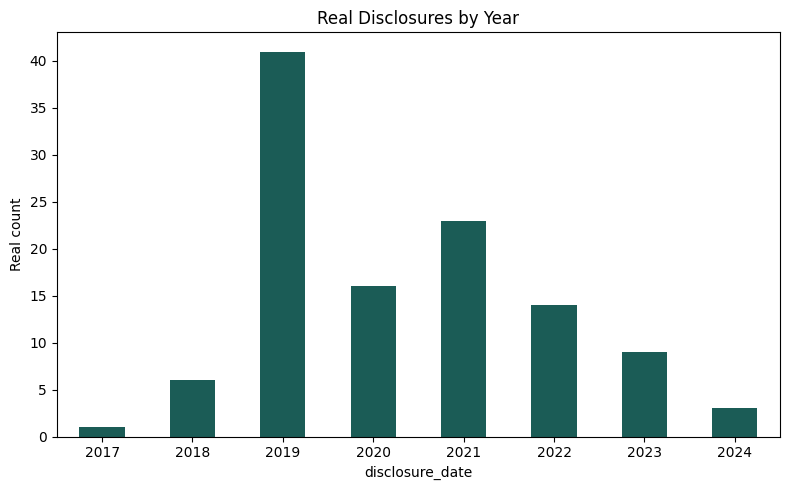

Saved rq4_eda_by_year.png


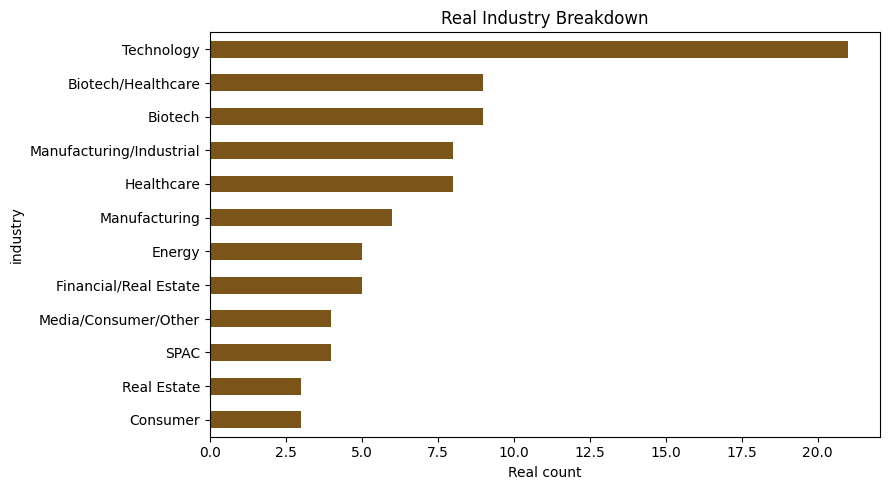

Saved rq4_eda_industry.png


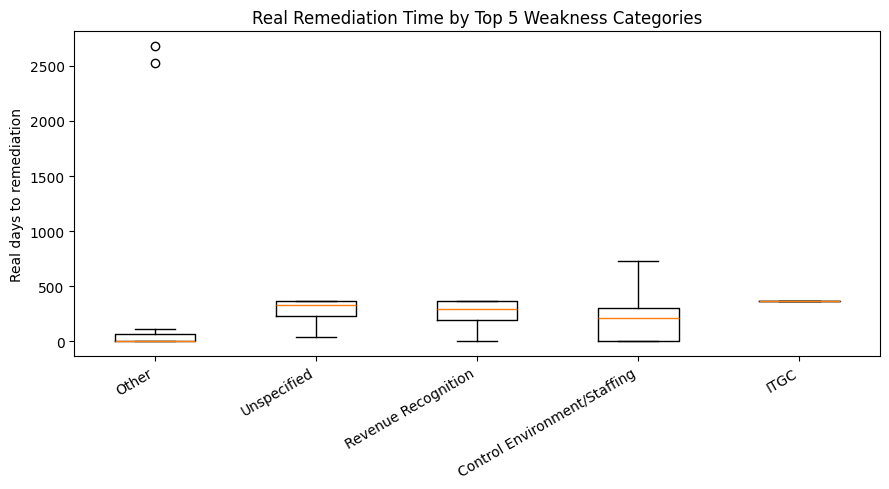

Saved rq4_eda_time_by_category.png


In [4]:
"""
RQ4 - PART 2: Real Exploratory Data Analysis
================================================================================
Real EDA for the SEC EDGAR material weakness dataset: remediation status,
weakness category breakdown, industry breakdown, and remediation time
distribution.
"""
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rq4_real_sec_edgar_dataset_FINAL.csv", parse_dates=["disclosure_date", "remediation_date"])
print(f"Real N = {len(df)}")
print(f"Real remediation status: {(df.event_observed==1).sum()} remediated, "
      f"{(df.event_observed==0).sum()} still open (censored)")

print("\n" + "="*70)
print("REAL SUMMARY STATISTICS: remediation_days (remediated cases only)")
print("="*70)
print(df[df.event_observed == 1]["remediation_days"].describe().round(1))

print("\n" + "="*70)
print("REAL FULL WEAKNESS CATEGORY COUNTS")
print("="*70)
print(df["weakness_category"].value_counts())

print("\n" + "="*70)
print("REAL FULL INDUSTRY COUNTS")
print("="*70)
print(df["industry"].value_counts())

print("\n" + "="*70)
print("REAL SOURCE FORM COUNTS (10-K, 10-Q, 8-K)")
print("="*70)
print(df["source_form"].value_counts())

# 1. Real remediation status
fig, ax = plt.subplots(figsize=(6, 5))
df["event_observed"].map({1: "Remediated", 0: "Still Open"}).value_counts().plot(
    kind="bar", ax=ax, color=["#1B5C56", "#7A5419"])
ax.set_title(f"Real Remediation Status (N={len(df)})")
ax.set_ylabel("Real count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rq4_eda_remediation_status.png", dpi=150)
plt.show()
print("Saved rq4_eda_remediation_status.png")

# 2. Real weakness category breakdown
fig, ax = plt.subplots(figsize=(9, 5))
df["weakness_category"].value_counts().head(12).plot(kind="barh", ax=ax, color="#1B5C56")
ax.set_title("Real Top Weakness Categories")
ax.set_xlabel("Real count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rq4_eda_weakness_categories.png", dpi=150)
plt.show()
print("Saved rq4_eda_weakness_categories.png")

# 3. Real remediation time distribution (for remediated cases only)
remediated = df[df.event_observed == 1]
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(remediated["remediation_days"], bins=30, color="#1B5C56", alpha=0.85)
ax.set_title(f"Real Remediation Time Distribution (N={len(remediated)} remediated)")
ax.set_xlabel("Real days to remediation")
ax.set_ylabel("Real count")
plt.tight_layout()
plt.savefig("rq4_eda_remediation_time.png", dpi=150)
plt.show()
print("Saved rq4_eda_remediation_time.png")
print(f"Real median: {remediated['remediation_days'].median():.0f} days, "
      f"real mean: {remediated['remediation_days'].mean():.0f} days")

# 4. Real disclosures by year
fig, ax = plt.subplots(figsize=(8, 5))
df["disclosure_date"].dt.year.value_counts().sort_index().plot(kind="bar", ax=ax, color="#1B5C56")
ax.set_title("Real Disclosures by Year")
ax.set_ylabel("Real count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("rq4_eda_by_year.png", dpi=150)
plt.show()
print("Saved rq4_eda_by_year.png")

# 5. Real industry breakdown (a genuine model predictor, was missing before)
fig, ax = plt.subplots(figsize=(9, 5))
df["industry"].value_counts().head(12).plot(kind="barh", ax=ax, color="#7A5419")
ax.set_title("Real Industry Breakdown")
ax.set_xlabel("Real count")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rq4_eda_industry.png", dpi=150)
plt.show()
print("Saved rq4_eda_industry.png")

# 6. Real remediation time by weakness category (top 5 categories)
top5_categories = df["weakness_category"].value_counts().head(5).index
subset = df[(df.weakness_category.isin(top5_categories)) & (df.event_observed == 1)]
fig, ax = plt.subplots(figsize=(9, 5))
data_by_cat = [subset[subset.weakness_category == c]["remediation_days"] for c in top5_categories]
ax.boxplot(data_by_cat, tick_labels=top5_categories)
ax.set_title("Real Remediation Time by Top 5 Weakness Categories")
ax.set_ylabel("Real days to remediation")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("rq4_eda_time_by_category.png", dpi=150)
plt.show()
print("Saved rq4_eda_time_by_category.png")
